In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

In [4]:
# Column names for NSL-KDD dataset (41 features + label)
columns = [
    "duration","protocol_type","service","flag","src_bytes","dst_bytes","land",
    "wrong_fragment","urgent","hot","num_failed_logins","logged_in",
    "num_compromised","root_shell","su_attempted","num_root","num_file_creations",
    "num_shells","num_access_files","num_outbound_cmds","is_host_login",
    "is_guest_login","count","srv_count","serror_rate","srv_serror_rate",
    "rerror_rate","srv_rerror_rate","same_srv_rate","diff_srv_rate",
    "srv_diff_host_rate","dst_host_count","dst_host_srv_count",
    "dst_host_same_srv_rate","dst_host_diff_srv_rate","dst_host_same_src_port_rate",
    "dst_host_srv_diff_host_rate","dst_host_serror_rate","dst_host_srv_serror_rate",
    "dst_host_rerror_rate","dst_host_srv_rerror_rate","label","difficulty"
]

# Load training data (KDDTrain+.txt)
url = "https://raw.githubusercontent.com/Mamcose/NSL-KDD-Network-Intrusion-Detection/master/NSL_KDD_Train.csv"
df = pd.read_csv(url, names=columns)

df.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,difficulty
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,NaN
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,NaN
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,NaN
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,NaN
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,NaN


In [5]:
print("Shape of dataset:", df.shape)
df.info()
print("\nLabel distribution:")
print(df['label'].value_counts())

Shape of dataset: (125973, 43)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125973 entries, 0 to 125972
Data columns (total 43 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   duration                     125973 non-null  int64  
 1   protocol_type                125973 non-null  object 
 2   service                      125973 non-null  object 
 3   flag                         125973 non-null  object 
 4   src_bytes                    125973 non-null  int64  
 5   dst_bytes                    125973 non-null  int64  
 6   land                         125973 non-null  int64  
 7   wrong_fragment               125973 non-null  int64  
 8   urgent                       125973 non-null  int64  
 9   hot                          125973 non-null  int64  
 10  num_failed_logins            125973 non-null  int64  
 11  logged_in                    125973 non-null  int64  
 12  num_compromised            

In [6]:
df['label'] = df['label'].apply(lambda x: 'normal' if x == 'normal' else 'attack')
df = df.drop(columns=['difficulty'])

print(df['label'].value_counts())

label
normal    67343
attack    58630
Name: count, dtype: int64


/tmp/ipykernel_765/683125253.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label', data=df, palette=['green','red'])


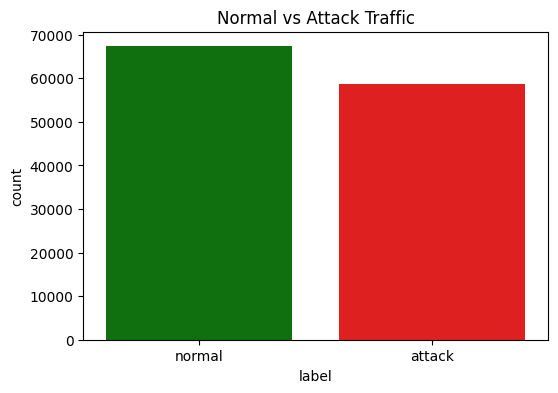

In [7]:
plt.figure(figsize=(6,4))
sns.countplot(x='label', data=df, palette=['green','red'])
plt.title("Normal vs Attack Traffic")
plt.show()

In [8]:
print("Missing values:\n", df.isnull().sum().sum())

Missing values:
 0


In [9]:
categorical_cols = ['protocol_type', 'service', 'flag']

label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le
target_encoder = LabelEncoder()
df['label'] = target_encoder.fit_transform(df['label'])

df.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label
0,0,1,20,9,491,0,0,0,0,0,...,25,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,1
1,0,2,44,9,146,0,0,0,0,0,...,1,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,1
2,0,1,49,5,0,0,0,0,0,0,...,26,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,0
3,0,1,24,9,232,8153,0,0,0,0,...,255,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,1
4,0,1,24,9,199,420,0,0,0,0,...,255,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1


In [10]:
X = df.drop(columns=['label'])
y = df['label']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (125973, 41)
Target shape: (125973,)


In [11]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Data scaled successfully!")

Data scaled successfully!


In [12]:
selector = SelectKBest(score_func=f_classif, k=15)
X_selected = selector.fit_transform(X_scaled, y)

selected_features = X.columns[selector.get_support()]
print("Selected Features:\n", list(selected_features))

Selected Features:
 ['protocol_type', 'service', 'flag', 'logged_in', 'count', 'serror_rate', 'srv_serror_rate', 'srv_rerror_rate', 'same_srv_rate', 'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_srv_rerror_rate']


/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:111: UserWarning: Features [19] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:112: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y, test_size=0.2, random_state=42, stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 100778
Testing samples: 25195


In [14]:
results = {}

def evaluate_model(name, model):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)

    results[name] = {"Accuracy": acc, "Precision": prec, "Recall": rec, "F1": f1}

    print(f"\n===== {name} =====")
    print(classification_report(y_test, y_pred, target_names=['normal','attack']))

    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Greens",
                xticklabels=['normal','attack'], yticklabels=['normal','attack'])
    plt.title(name + " - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    return model


===== Logistic Regression =====
              precision    recall  f1-score   support

      normal       0.95      0.91      0.93     11726
      attack       0.93      0.96      0.94     13469

    accuracy                           0.94     25195
   macro avg       0.94      0.94      0.94     25195
weighted avg       0.94      0.94      0.94     25195



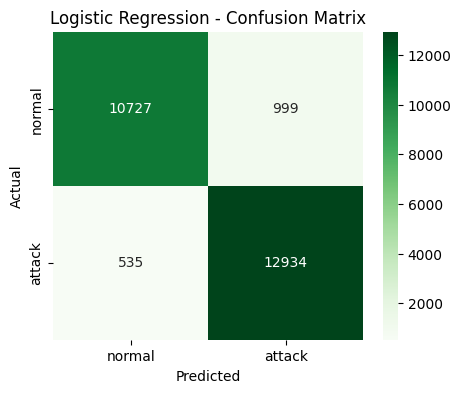

In [15]:
log_model = LogisticRegression(max_iter=1000)
log_model = evaluate_model("Logistic Regression", log_model)


===== Random Forest =====
              precision    recall  f1-score   support

      normal       0.99      1.00      0.99     11726
      attack       1.00      0.99      1.00     13469

    accuracy                           1.00     25195
   macro avg       1.00      1.00      1.00     25195
weighted avg       1.00      1.00      1.00     25195



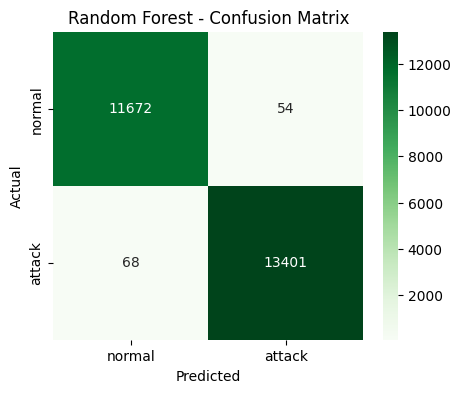

In [16]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model = evaluate_model("Random Forest", rf_model)


===== Neural Network (MLP) =====
              precision    recall  f1-score   support

      normal       0.98      0.99      0.99     11726
      attack       0.99      0.99      0.99     13469

    accuracy                           0.99     25195
   macro avg       0.99      0.99      0.99     25195
weighted avg       0.99      0.99      0.99     25195



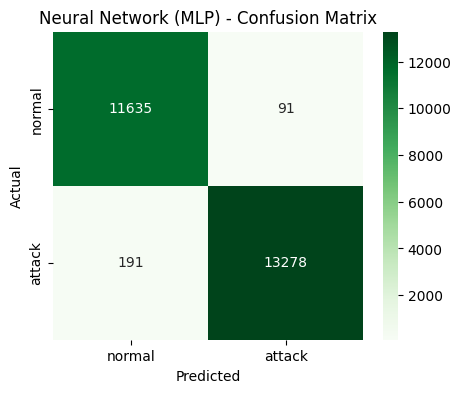

In [17]:
mlp_model = MLPClassifier(hidden_layer_sizes=(32,16), max_iter=300, random_state=42)
mlp_model = evaluate_model("Neural Network (MLP)", mlp_model)

Actual       0      1
Cluster              
0        11834  67112
1        46796    231


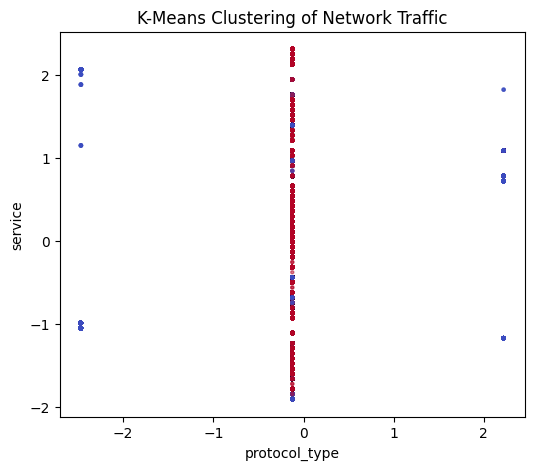

In [18]:
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_selected)
comparison_df = pd.DataFrame({'Actual': y, 'Cluster': clusters})
print(pd.crosstab(comparison_df['Cluster'], comparison_df['Actual']))
plt.figure(figsize=(6,5))
plt.scatter(X_selected[:,0], X_selected[:,1], c=clusters, cmap='coolwarm', alpha=0.5, s=5)
plt.title("K-Means Clustering of Network Traffic")
plt.xlabel(selected_features[0])
plt.ylabel(selected_features[1])
plt.show()

                      Accuracy  Precision    Recall        F1
Logistic Regression   0.939115   0.928300  0.960279  0.944019
Random Forest         0.995158   0.995987  0.994951  0.995469
Neural Network (MLP)  0.988807   0.993193  0.985819  0.989493


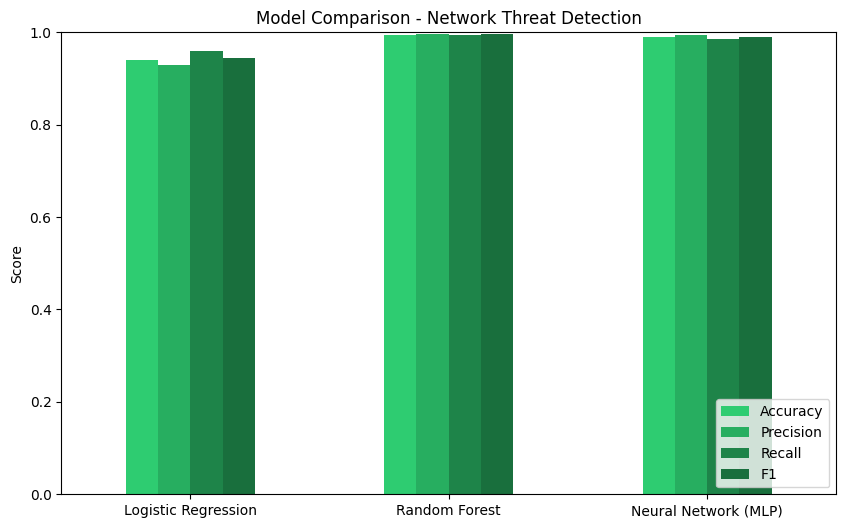

In [19]:
results_df = pd.DataFrame(results).T
print(results_df)

results_df.plot(kind="bar", figsize=(10,6), color=['#2ecc71','#27ae60','#1e8449','#196f3d'])
plt.title("Model Comparison - Network Threat Detection")
plt.ylabel("Score")
plt.ylim(0,1)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.show()

In [20]:
best_model = results_df["F1"].idxmax()
print("Best Model based on F1 Score:", best_model)
print(results_df.loc[best_model])

Best Model based on F1 Score: Random Forest
Accuracy     0.995158
Precision    0.995987
Recall       0.994951
F1           0.995469
Name: Random Forest, dtype: float64


In [21]:
import joblib, json

joblib.dump(log_model, "log_model.pkl")
joblib.dump(rf_model, "rf_model.pkl")
joblib.dump(mlp_model, "mlp_model.pkl")
joblib.dump(kmeans, "kmeans_model.pkl")

joblib.dump(scaler, "scaler.pkl")
joblib.dump(selector, "selector.pkl")
joblib.dump(label_encoders, "label_encoders.pkl")
joblib.dump(target_encoder, "target_encoder.pkl")

with open("selected_features.json", "w") as f:
    json.dump(list(selected_features), f)

with open("all_features.json", "w") as f:
    json.dump(list(X.columns), f)

with open("categorical_cols.json", "w") as f:
    json.dump(categorical_cols, f)

results_df.to_csv("results_df.csv")

print("All files saved!")

from google.colab import files
for f in ["log_model.pkl","rf_model.pkl","mlp_model.pkl","kmeans_model.pkl",
          "scaler.pkl","selector.pkl","label_encoders.pkl","target_encoder.pkl",
          "selected_features.json","all_features.json","categorical_cols.json","results_df.csv"]:
    files.download(f)

All files saved!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>